In [22]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Find the project folder.
repo = Path.cwd()
while not (repo / "output" / "benchmark_ggm.txt").exists():
    if repo.parent == repo:
        raise FileNotFoundError("Cannot find output/benchmark_ggm.txt")
    repo = repo.parent

benchmark_file = repo / "output" / "benchmark_ggm.txt"
figure_dir = repo / "docs" / "results" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

print("Benchmark file:", benchmark_file)
print("Figure folder:", figure_dir)


Benchmark file: c:\Users\Mark\Documents\GitHub\ECE268-GGM-Tree-Construction\output\benchmark_ggm.txt
Figure folder: c:\Users\Mark\Documents\GitHub\ECE268-GGM-Tree-Construction\docs\results\figures


## Load benchmark data

Read the benchmark output and keep only the result rows.

In [23]:
rows = []

for line in benchmark_file.read_text().splitlines():
    line = line.strip()
    if line.startswith("Spongent") or line.startswith("Keccak"):
        parts = line.split(",")
        rows.append({
            "prf": parts[0],
            "platform": parts[1],
            "depth": int(parts[2]),
            "leaves": int(parts[3]),
            "best_ms": float(parts[4]),
            "leaves_per_sec": float(parts[5]),
        })

df = pd.DataFrame(rows)
df


,prf,platform,depth,leaves,best_ms,leaves_per_sec
0,Spongent,CPU,8,256,508.696,503.25
1,Spongent,GPU,8,256,1320.095,193.93
2,Keccak,CPU,8,256,1.948,131416.97
3,Keccak,GPU,8,256,1.561,164045.06
4,Spongent,CPU,12,4096,8358.142,490.06
5,Spongent,GPU,12,4096,2041.876,2006.00
6,Keccak,CPU,12,4096,24.288,168640.66
7,Keccak,GPU,12,4096,1.726,2372679.39


## Plot settings

I used UCSD-style colors and kept the same colors across the charts.

In [24]:
colors = {
    "CPU": "#182B49",       # UCSD navy
    "GPU": "#FFCD00",       # UCSD gold
    "Spongent": "#00629B",  # UCSD ocean blue
    "Keccak": "#C69214",    # darker gold
}

depths = sorted(df["depth"].unique())

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
})

def get_value(prf, platform, depth, column):
    row = df[(df["prf"] == prf) & (df["platform"] == platform) & (df["depth"] == depth)]
    return row.iloc[0][column]


## Chart 1: Spongent CPU vs GPU

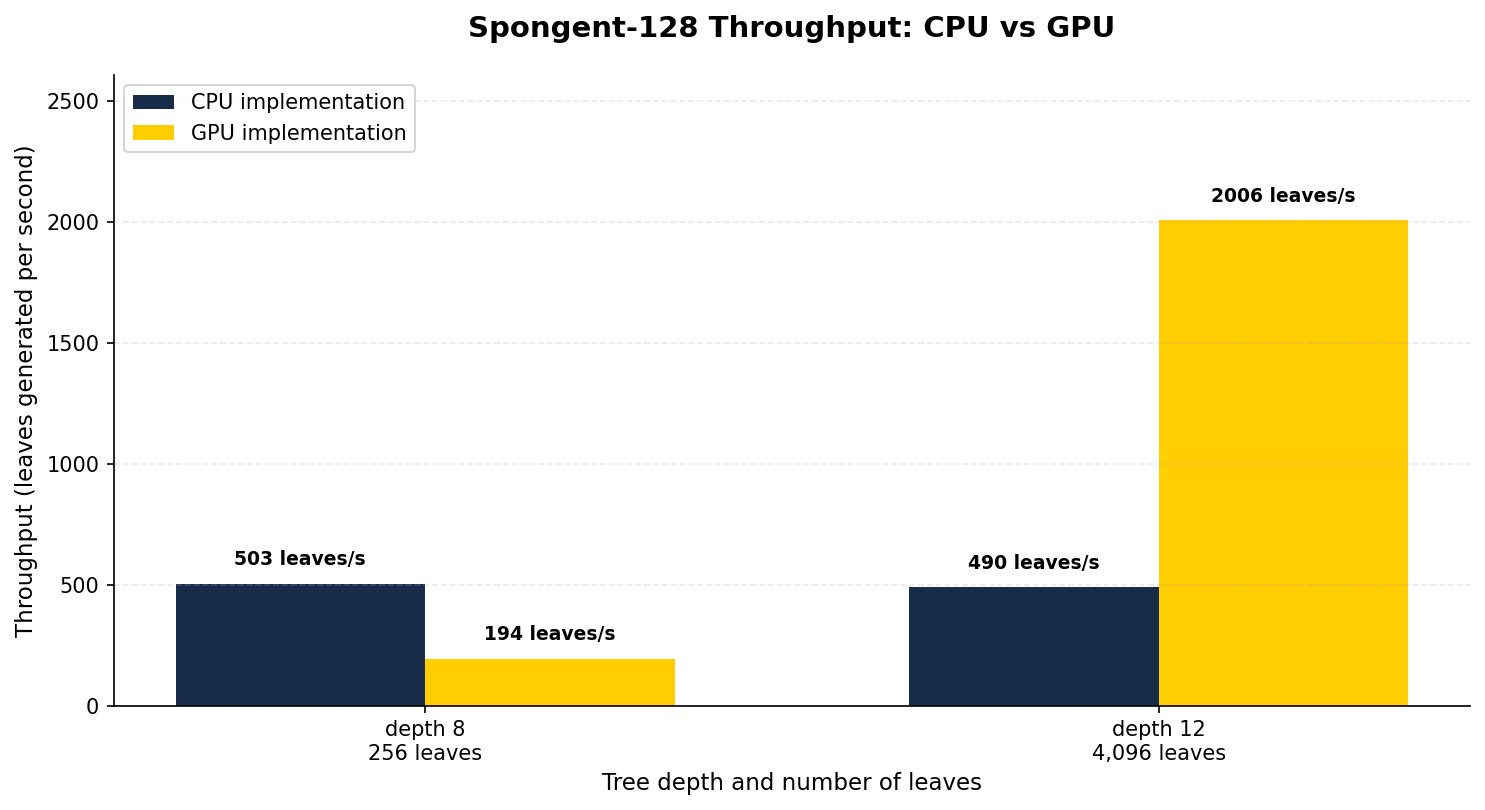

Saved: c:\Users\Mark\Documents\GitHub\ECE268-GGM-Tree-Construction\docs\results\figures\spongent_cpu_gpu_throughput.png


In [25]:
prf = "Spongent"
x = np.arange(len(depths))
width = 0.34

cpu_values = [get_value(prf, "CPU", d, "leaves_per_sec") for d in depths]
gpu_values = [get_value(prf, "GPU", d, "leaves_per_sec") for d in depths]

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

cpu_bars = ax.bar(x - width / 2, cpu_values, width, label="CPU implementation", color=colors["CPU"])
gpu_bars = ax.bar(x + width / 2, gpu_values, width, label="GPU implementation", color=colors["GPU"])

# Add space at the top so labels do not hit the title.
max_value = max(cpu_values + gpu_values)
ax.set_ylim(0, max_value * 1.30)

for bars, values in [(cpu_bars, cpu_values), (gpu_bars, gpu_values)]:
    for bar, value in zip(bars, values):
        label = f"{value:.0f} leaves/s"
        ax.text(bar.get_x() + bar.get_width() / 2, value + max_value * 0.03,
                label, ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("Spongent-128 Throughput: CPU vs GPU", pad=18)
ax.set_ylabel("Throughput (leaves generated per second)")
ax.set_xlabel("Tree depth and number of leaves")
ax.set_xticks(x)
ax.set_xticklabels([f"depth {d}\n{2 ** d:,} leaves" for d in depths])
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

chart_path = figure_dir / "spongent_cpu_gpu_throughput.png"
fig.tight_layout()
fig.savefig(chart_path, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)


### Conclusion: Spongent CPU vs GPU

For Spongent, the GPU is slower at depth 8 because the tree is still small and CUDA launch overhead is noticeable. At depth 12, the GPU becomes faster because there are more nodes that can be expanded in parallel.

## Chart 2: Keccak CPU vs GPU

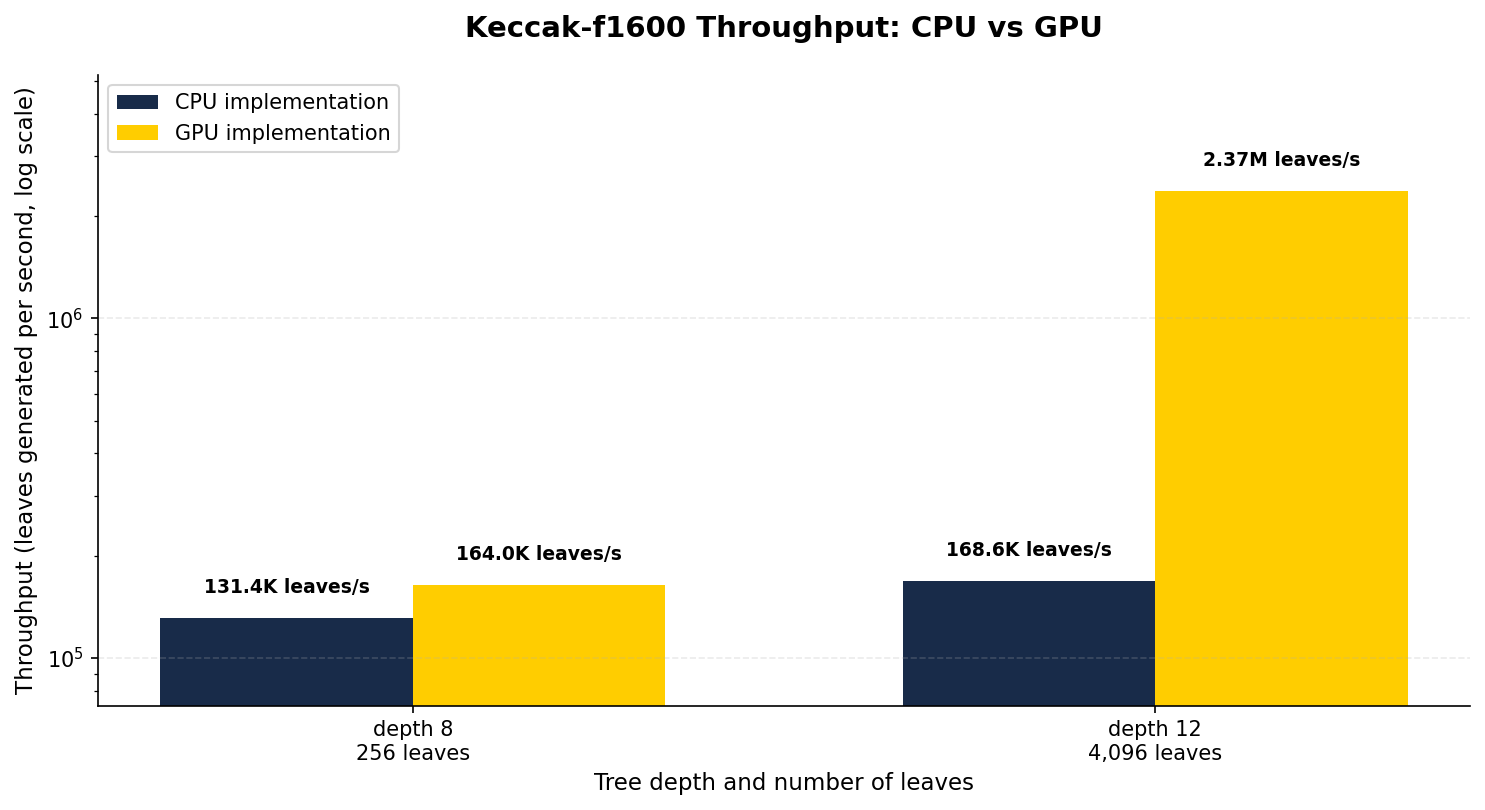

Saved: c:\Users\Mark\Documents\GitHub\ECE268-GGM-Tree-Construction\docs\results\figures\keccak_cpu_gpu_throughput.png


In [26]:
prf = "Keccak"
x = np.arange(len(depths))
width = 0.34

cpu_values = [get_value(prf, "CPU", d, "leaves_per_sec") for d in depths]
gpu_values = [get_value(prf, "GPU", d, "leaves_per_sec") for d in depths]

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

cpu_bars = ax.bar(x - width / 2, cpu_values, width, label="CPU implementation", color=colors["CPU"])
gpu_bars = ax.bar(x + width / 2, gpu_values, width, label="GPU implementation", color=colors["GPU"])

# Keccak values are far apart, so log scale makes both bars readable.
all_values = cpu_values + gpu_values
ax.set_yscale("log")
ax.set_ylim(min(all_values) * 0.55, max(all_values) * 2.20)

for bars, values in [(cpu_bars, cpu_values), (gpu_bars, gpu_values)]:
    for bar, value in zip(bars, values):
        if value >= 1_000_000:
            label = f"{value / 1_000_000:.2f}M leaves/s"
        else:
            label = f"{value / 1_000:.1f}K leaves/s"
        ax.text(bar.get_x() + bar.get_width() / 2, value * 1.15,
                label, ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("Keccak-f1600 Throughput: CPU vs GPU", pad=18)
ax.set_ylabel("Throughput (leaves generated per second, log scale)")
ax.set_xlabel("Tree depth and number of leaves")
ax.set_xticks(x)
ax.set_xticklabels([f"depth {d}\n{2 ** d:,} leaves" for d in depths])
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

chart_path = figure_dir / "keccak_cpu_gpu_throughput.png"
fig.tight_layout()
fig.savefig(chart_path, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)


### Conclusion: Keccak CPU vs GPU

Keccak is faster than Spongent overall. The GPU version is only slightly faster at depth 8, but at depth 12 it becomes much faster because the GPU has more parallel work to do.

## Chart 3: GPU speedup

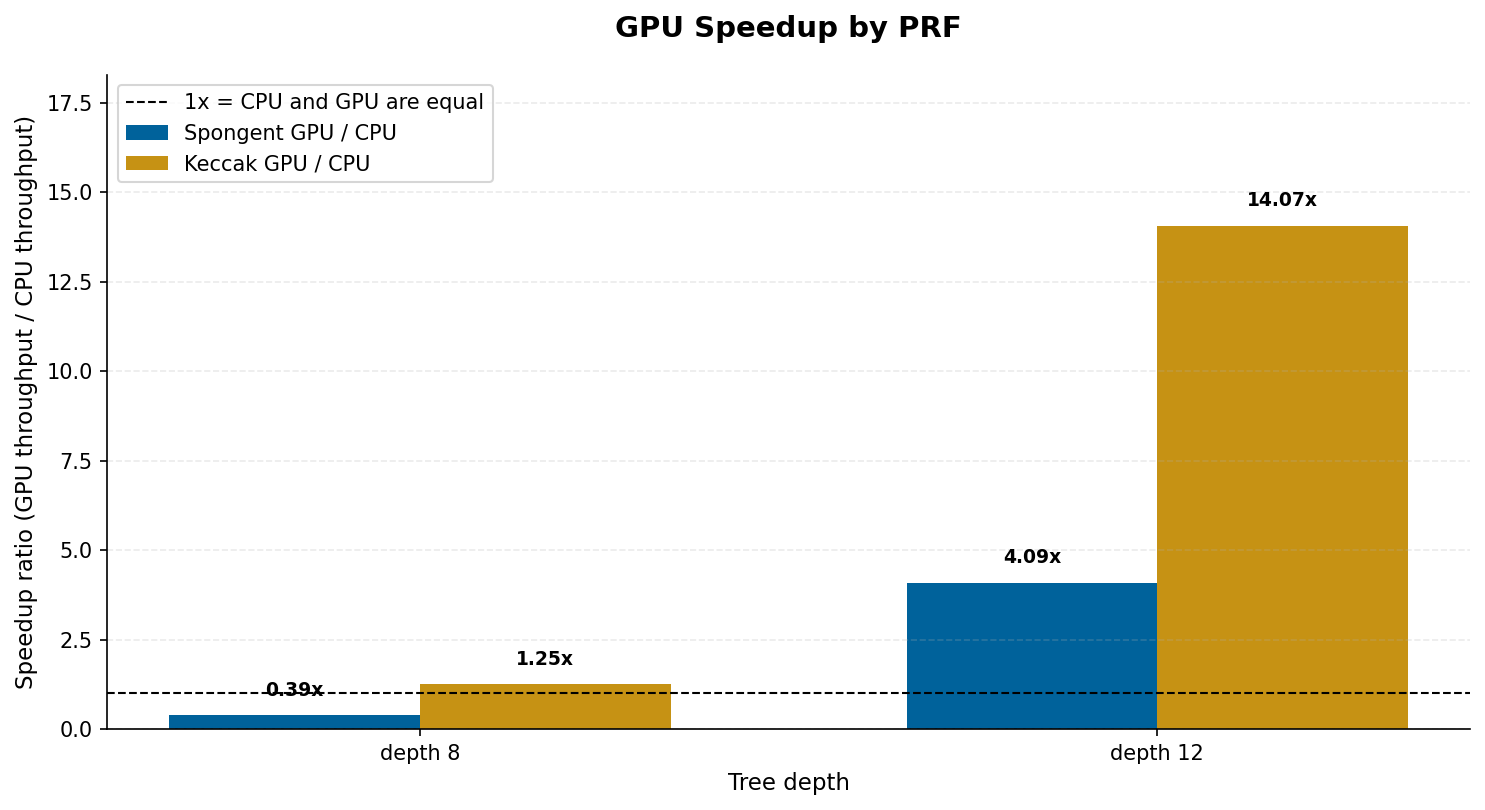

Saved: c:\Users\Mark\Documents\GitHub\ECE268-GGM-Tree-Construction\docs\results\figures\gpu_speedup_by_prf.png


,depth,prf,speedup
0,8,Spongent,0.385355
1,8,Keccak,1.248279
2,12,Spongent,4.093376
3,12,Keccak,14.069438


In [27]:
speedup_rows = []

for depth in depths:
    for prf in ["Spongent", "Keccak"]:
        cpu_rate = get_value(prf, "CPU", depth, "leaves_per_sec")
        gpu_rate = get_value(prf, "GPU", depth, "leaves_per_sec")
        speedup_rows.append({"depth": depth, "prf": prf, "speedup": gpu_rate / cpu_rate})

speedup_df = pd.DataFrame(speedup_rows)

x = np.arange(len(depths))
width = 0.34

spongent_speedup = [speedup_df[(speedup_df["prf"] == "Spongent") & (speedup_df["depth"] == d)].iloc[0]["speedup"] for d in depths]
keccak_speedup = [speedup_df[(speedup_df["prf"] == "Keccak") & (speedup_df["depth"] == d)].iloc[0]["speedup"] for d in depths]

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

spongent_bars = ax.bar(x - width / 2, spongent_speedup, width, label="Spongent GPU / CPU", color=colors["Spongent"])
keccak_bars = ax.bar(x + width / 2, keccak_speedup, width, label="Keccak GPU / CPU", color=colors["Keccak"])

max_value = max(spongent_speedup + keccak_speedup)
ax.set_ylim(0, max_value * 1.30)

for bars, values in [(spongent_bars, spongent_speedup), (keccak_bars, keccak_speedup)]:
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + max_value * 0.03,
                f"{value:.2f}x", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="1x = CPU and GPU are equal")
ax.set_title("GPU Speedup by PRF", pad=18)
ax.set_ylabel("Speedup ratio (GPU throughput / CPU throughput)")
ax.set_xlabel("Tree depth")
ax.set_xticks(x)
ax.set_xticklabels([f"depth {d}" for d in depths])
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

chart_path = figure_dir / "gpu_speedup_by_prf.png"
fig.tight_layout()
fig.savefig(chart_path, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)
speedup_df


### Conclusion: GPU Speedup

The speedup chart shows the main scaling trend. Small trees do not always benefit from GPU execution, but larger trees do. Keccak has the stronger GPU speedup, while Spongent also improves once the depth is large enough.

## Chart 4: Runtime at the largest tested depth

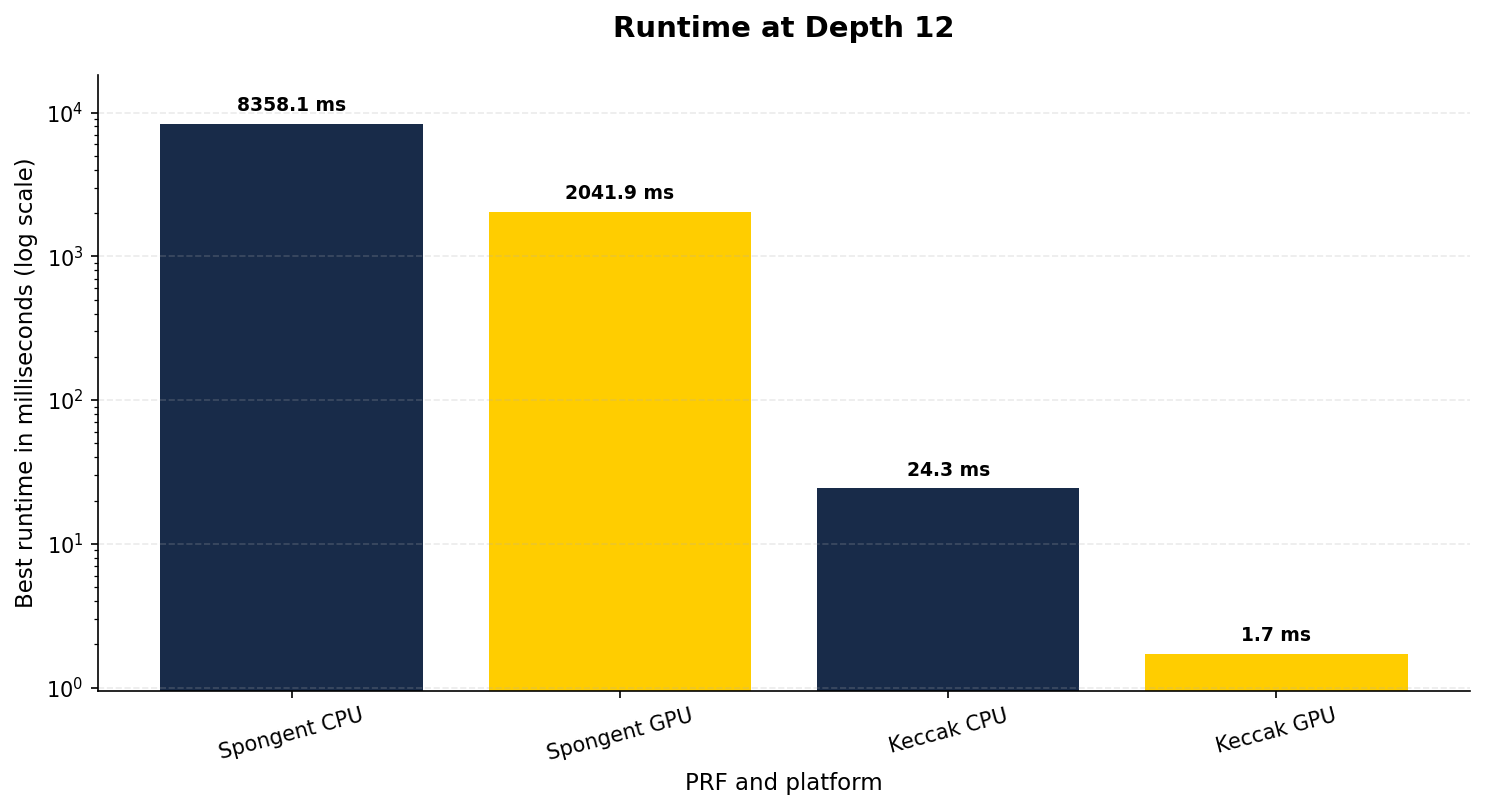

Saved: c:\Users\Mark\Documents\GitHub\ECE268-GGM-Tree-Construction\docs\results\figures\runtime_depth_12.png


In [28]:
largest_depth = max(depths)

labels = ["Spongent CPU", "Spongent GPU", "Keccak CPU", "Keccak GPU"]
time_values = [
    get_value("Spongent", "CPU", largest_depth, "best_ms"),
    get_value("Spongent", "GPU", largest_depth, "best_ms"),
    get_value("Keccak", "CPU", largest_depth, "best_ms"),
    get_value("Keccak", "GPU", largest_depth, "best_ms"),
]
bar_colors = [colors["CPU"], colors["GPU"], colors["CPU"], colors["GPU"]]

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)
bars = ax.bar(labels, time_values, color=bar_colors)

ax.set_yscale("log")
ax.set_ylim(min(time_values) * 0.55, max(time_values) * 2.20)

for bar, value in zip(bars, time_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value * 1.15,
            f"{value:.1f} ms", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title(f"Runtime at Depth {largest_depth}", pad=18)
ax.set_ylabel("Best runtime in milliseconds (log scale)")
ax.set_xlabel("PRF and platform")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

chart_path = figure_dir / "runtime_depth_12.png"
fig.tight_layout()
fig.savefig(chart_path, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)


### Conclusion: Runtime at Depth 12

At depth 12, the GPU version reduces runtime for both PRFs. Keccak GPU is the fastest case overall, while Spongent CPU is the slowest because the Spongent PRF work is much heavier in this implementation.